In [1]:
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt

def load_data(filepath: str) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    df = pd.read_csv(filepath, header=None)
        
    x = df.iloc[:, 0].to_numpy().reshape(-1, 1).astype(np.float64)
    y = df.iloc[:, 1].to_numpy().reshape(-1, 1).astype(np.float64)
    return x, y

In [2]:
import numpy as np
from typing import Tuple, List

def calc_mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calcula o Erro Quadrático Médio (MSE)."""
    return np.mean((y_true - y_pred) ** 2)

def calc_gd(X: np.ndarray,
            y: np.ndarray, 
            learning_rate: float = 0.1, 
            epochs: int = 100) -> Tuple[np.ndarray, float, List[float]]:
    # Garante que X seja 2D e adiciona a coluna de 1s para o bias (intercepto)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]
    y = y.ravel()
    
    # Inicialização dos parâmetros (theta) com zeros
    theta = np.zeros(X_b.shape[1])
    learning_curve = []
    
    for _ in range(epochs):
        # Predição e cálculo do erro
        predictions = X_b.dot(theta)
        errors = predictions - y
        
        # Grava o MSE da época atual
        mse = calc_mse(y, predictions)
        learning_curve.append(mse)
        
        # Cálculo dos gradientes e atualização dos pesos
        gradients = (2 / m) * X_b.T.dot(errors)
        theta -= learning_rate * gradients
        
    # Calcula o MSE final
    final_mse = calc_mse(y, X_b.dot(theta))
    
    return theta, final_mse, learning_curve

def calc_sgd(X: np.ndarray, y: np.ndarray, 
    learning_rate: float = 0.01, 
    epochs: int = 50,
    random_state: int = 42) -> Tuple[np.ndarray, float, List[float]]:

    if X.ndim == 1:
        X = X.reshape(-1, 1)
        
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]
    y = y.ravel()
    
    # Seed para reprodutibilidade do embaralhamento
    rng = np.random.default_rng(seed=random_state)
    theta = np.zeros(X_b.shape[1])
    learning_curve = []
    
    for epoch in range(epochs):
        # Embaralha os dados no início de cada época para evitar ciclos
        permutation = rng.permutation(m)
        X_shuffled = X_b[permutation]
        y_shuffled = y[permutation]
        
        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            
            prediction = xi.dot(theta)
            error = prediction - yi
            
            # O gradiente para uma única amostra não é dividido por 'm'
            gradients = 2 * xi.T.dot(error)
            theta -= learning_rate * gradients
            
        # Calcula o MSE no final da época usando todos os dados (para a curva)
        mse_epoch = calc_mse(y, X_b.dot(theta))
        learning_curve.append(mse_epoch)
        
    final_mse = calc_mse(y, X_b.dot(theta))
    
    return theta, final_mse, learning_curve


def calc_ols(x: npt.NDArray[np.float64], y: npt.NDArray[np.float64]) -> tuple[npt.NDArray[np.float64], float]:
    samples = x.shape[0]
    
    # Construção da Matriz de Design X (bias + feature)
    X = np.hstack([np.ones((samples, 1)), x])
    
    # OLS: w = inversa(X^T * X) * X^T * y
    X_T = X.T
    w_predict = np.linalg.inv(X_T @ X) @ X_T @ y
    
    # predição e mse
    y_predict = X @ w_predict
    mse = float(np.mean((y - y_predict) ** 2))
    
    return w_predict, mse

In [3]:
def plotar(
    x: npt.NDArray[np.float64], 
    y: npt.NDArray[np.float64], 
    w_predict: npt.NDArray[np.float64], 
    filepath: str = 'plot/regression_plot.png',
    regression_type: str = '???'
) -> None:
    X = np.hstack([np.ones((x.shape[0], 1)), x])
    y_predict = X @ w_predict
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='steelblue', alpha=0.7, label=f'Dados')
    
    # Ordenando para garantir que a linha seja plotada corretamente
    w = w_predict.ravel()
    sort_idx = np.argsort(x[:, 0])
    plt.plot(x[sort_idx], y_predict[sort_idx], color='darkred', linewidth=2, 
             label=f'{regression_type}: y_predict = {w[0]:.4f} + {w[1]:.4f}x')

    plt.xlabel('Variável Independente (x)')
    plt.ylabel('Variável Dependente (y)')
    plt.title(f'Regressão Linear ({regression_type})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300)

OLS MSE: 0.2134009013


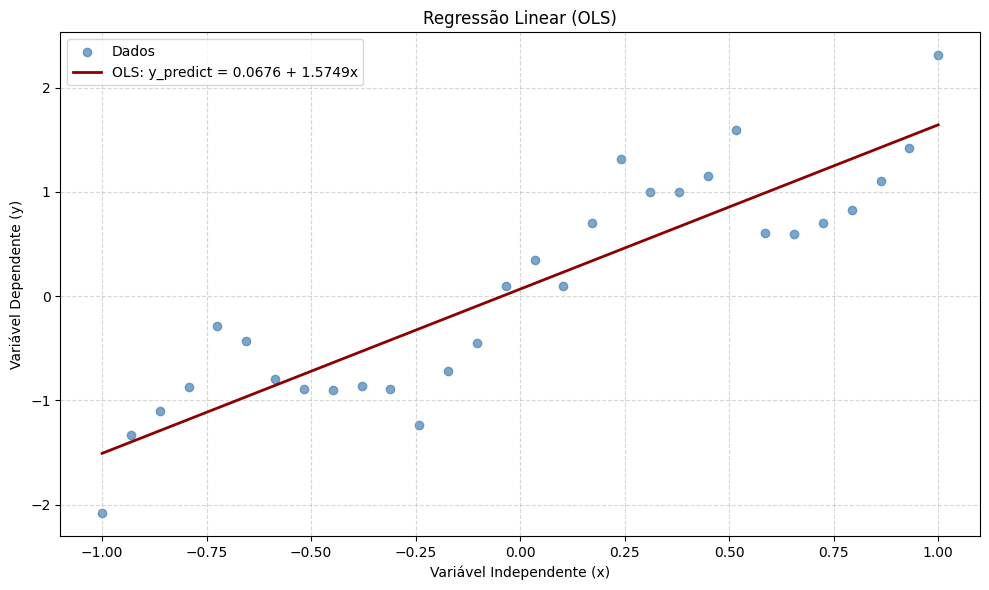

In [4]:
# Questão 1, item a
x, y = load_data('data/artificial1d.csv')
w_predict, mse = calc_ols(x, y)
plotar(x, y, w_predict, filepath='plot/1a_ols.png', regression_type='OLS')
print(f'OLS MSE: {mse:.10f}')

GD MSE: 0.2134012361


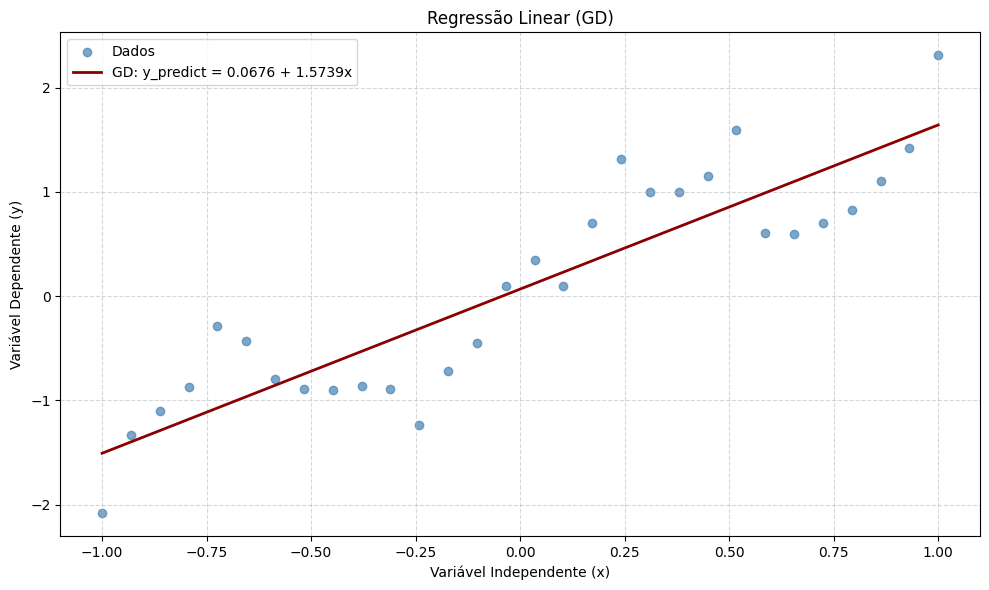

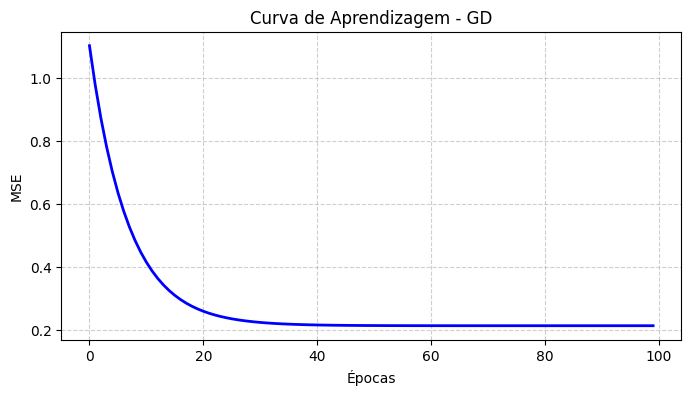

In [5]:
# Questão 1, item b
x, y = load_data('data/artificial1d.csv')
w_predict, mse, learning_curve = calc_gd(x, y)
plotar(x, y, w_predict, filepath='plot/1b_gd.png', regression_type='GD')
print(f'GD MSE: {mse:.10f}')

plt.figure(figsize=(8, 4))
plt.plot(learning_curve, color='blue', linewidth=2)
plt.title('Curva de Aprendizagem - GD')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.grid(True, linestyle='--', alpha=0.6)

SGD MSE: 0.2134023122


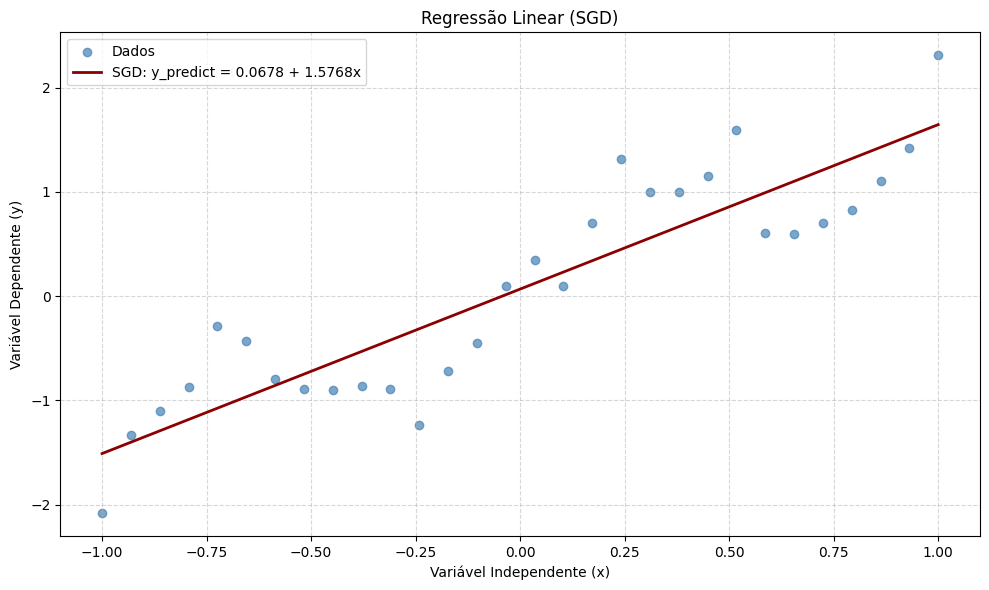

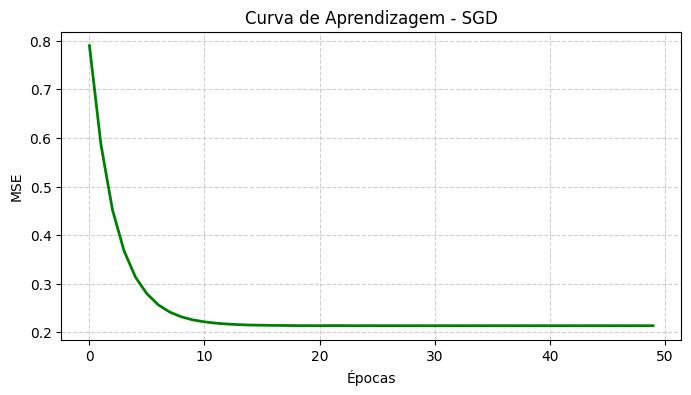

In [6]:
# Questão 1, item c
x, y = load_data('data/artificial1d.csv')
w_predict, mse, learning_curve = calc_sgd(x, y)
plotar(x, y, w_predict, filepath='plot/1c_sgd.png', regression_type='SGD')
print(f'SGD MSE: {mse:.10f}')

plt.figure(figsize=(8, 4))
plt.plot(learning_curve, color='green', linewidth=2)
plt.title('Curva de Aprendizagem - SGD')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.grid(True, linestyle='--', alpha=0.6)

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from typing import Dict, Tuple

def create_polynomial_features(X: np.ndarray, degree: int) -> np.ndarray:
    features = [X ** d for d in range(1, degree + 1)]
    return np.hstack(features)

def add_bias(X: np.ndarray) -> np.ndarray:
    return np.hstack((np.ones((X.shape[0], 1)), X))

# Questão 2, item a
df = pd.read_csv('data/california.csv', header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1) # Reshape necessário para o StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42069
)

In [8]:
# Questão 2, item b

scaler_x = MinMaxScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

models: Dict[int, np.ndarray] = {}

print("Iniciando treinamento dos modelos (Graus 1 a 13)...")

for degree in range(1, 14):
    # Utiliza expansão sem interações explícita (from scratch) p/ evitar OOM
    X_poly_train = create_polynomial_features(X_train_scaled, degree)
    X_poly_train = add_bias(X_poly_train)
    
    # OLS com pseudoinversa para evitar instabilidade
    theta = np.linalg.pinv(X_poly_train) @ y_train_scaled
    
    models[degree] = theta
    print(f"[Sucesso] Grau {degree:2d} | Features geradas: {X_poly_train.shape[1]}")


Iniciando treinamento dos modelos (Graus 1 a 13)...
[Sucesso] Grau  1 | Features geradas: 9
[Sucesso] Grau  2 | Features geradas: 17
[Sucesso] Grau  3 | Features geradas: 25
[Sucesso] Grau  4 | Features geradas: 33
[Sucesso] Grau  5 | Features geradas: 41
[Sucesso] Grau  6 | Features geradas: 49
[Sucesso] Grau  7 | Features geradas: 57
[Sucesso] Grau  8 | Features geradas: 65
[Sucesso] Grau  9 | Features geradas: 73
[Sucesso] Grau 10 | Features geradas: 81
[Sucesso] Grau 11 | Features geradas: 89
[Sucesso] Grau 12 | Features geradas: 97
[Sucesso] Grau 13 | Features geradas: 105


In [9]:
import matplotlib.pyplot as plt

rmse_train_list = []
rmse_test_list = []

# Pegamos apenas os graus que treinaram com sucesso (evitando falhas por MemoryError)
degrees = list(models.keys()) 

print("Calculando predições e RMSE para Treino e Teste...")

for degree in degrees:
    # 1. Recriar expansão polinomial para as features normalizadas (sem interações)
    X_poly_train = create_polynomial_features(X_train_scaled, degree)
    X_poly_train = add_bias(X_poly_train)
    
    X_poly_test = create_polynomial_features(X_test_scaled, degree)
    X_poly_test = add_bias(X_poly_test)
    
    # 2. Resgatar os pesos (theta) treinados do dicionário
    theta = models[degree]
    
    # 3. Predição (A saída estará em escala normalizada Z-score)
    y_train_pred_scaled = X_poly_train @ theta
    y_test_pred_scaled = X_poly_test @ theta
    
    # 4. "Desnormalizar" (inverter a escala) para voltar aos preços reais (dólares)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))
    
    # Nota: y_train e y_test originais já são os dados desnormalizados!
    
    # 5. Calcular RMSE achatando com .ravel() por extrema segurança
    rmse_train = np.sqrt(np.mean((y_train.ravel() - y_train_pred.ravel()) ** 2))
    rmse_test = np.sqrt(np.mean((y_test.ravel() - y_test_pred.ravel()) ** 2))
    
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)


Calculando predições e RMSE para Treino e Teste...


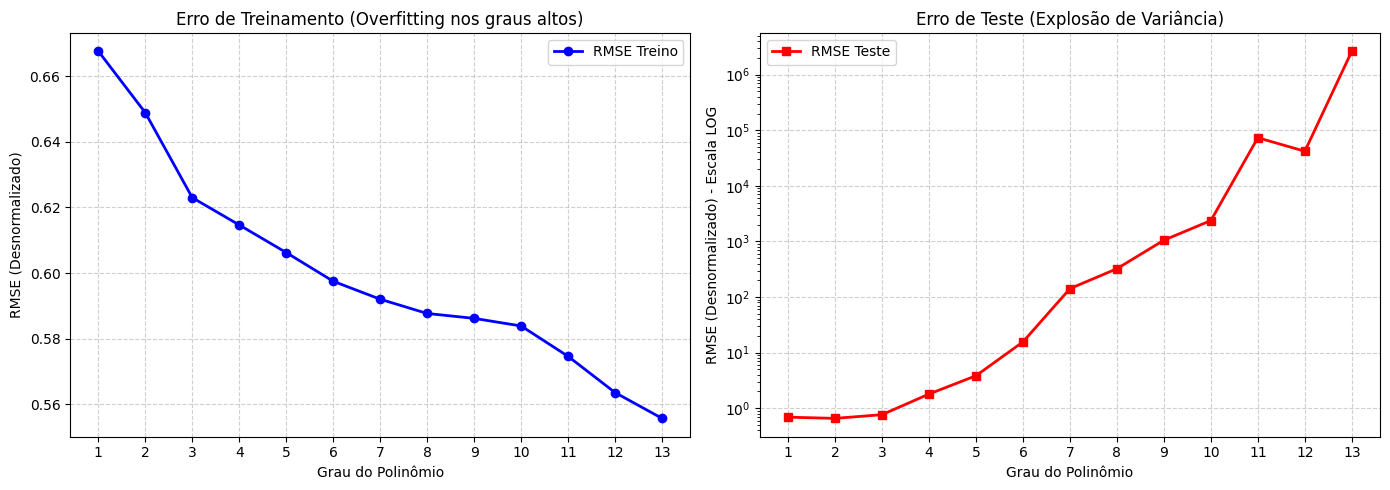


[Resumo dos Erros]
Grau  1 | RMSE Treino:       0.67 | RMSE Teste:         0.69
Grau  2 | RMSE Treino:       0.65 | RMSE Teste:         0.66
Grau  3 | RMSE Treino:       0.62 | RMSE Teste:         0.76
Grau  4 | RMSE Treino:       0.61 | RMSE Teste:         1.80
Grau  5 | RMSE Treino:       0.61 | RMSE Teste:         3.84
Grau  6 | RMSE Treino:       0.60 | RMSE Teste:        15.60
Grau  7 | RMSE Treino:       0.59 | RMSE Teste:       141.55
Grau  8 | RMSE Treino:       0.59 | RMSE Teste:       323.38
Grau  9 | RMSE Treino:       0.59 | RMSE Teste:      1053.18
Grau 10 | RMSE Treino:       0.58 | RMSE Teste:      2377.40
Grau 11 | RMSE Treino:       0.57 | RMSE Teste:     73397.27
Grau 12 | RMSE Treino:       0.56 | RMSE Teste:     41910.38
Grau 13 | RMSE Treino:       0.56 | RMSE Teste:   2645343.33


In [12]:
plt.figure(figsize=(14, 5))

# Gráfico do Treino
plt.subplot(1, 2, 1)
plt.plot(degrees, rmse_train_list, marker='o', color='blue', linewidth=2, label='RMSE Treino')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE (Desnormalizado)')
plt.title('Erro de Treinamento (Overfitting nos graus altos)')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfico do Teste
plt.subplot(1, 2, 2)
plt.plot(degrees, rmse_test_list, marker='s', color='red', linewidth=2, label='RMSE Teste')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE (Desnormalizado) - Escala LOG')
plt.title('Erro de Teste (Explosão de Variância)')
plt.xticks(degrees)
plt.yscale('log') # ESCALA LOGARÍTMICA CRUCIAL AQUI!
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# Exibe os valores para conferência rápida
print("\n[Resumo dos Erros]")
for d, tr_err, te_err in zip(degrees, rmse_train_list, rmse_test_list):
    print(f"Grau {d:2d} | RMSE Treino: {tr_err:10.2f} | RMSE Teste: {te_err:12.2f}")

Treinando modelos com Regularização L2 (λ = 0.01)...
[Sucesso] Grau  1 | RMSE Teste:       0.69
[Sucesso] Grau  2 | RMSE Teste:       0.66
[Sucesso] Grau  3 | RMSE Teste:       0.65
[Sucesso] Grau  4 | RMSE Teste:       0.66
[Sucesso] Grau  5 | RMSE Teste:       0.69
[Sucesso] Grau  6 | RMSE Teste:       0.70
[Sucesso] Grau  7 | RMSE Teste:       0.65
[Sucesso] Grau  8 | RMSE Teste:       0.97
[Sucesso] Grau  9 | RMSE Teste:       2.14
[Sucesso] Grau 10 | RMSE Teste:       4.22
[Sucesso] Grau 11 | RMSE Teste:       7.42
[Sucesso] Grau 12 | RMSE Teste:      12.08
[Sucesso] Grau 13 | RMSE Teste:      18.72


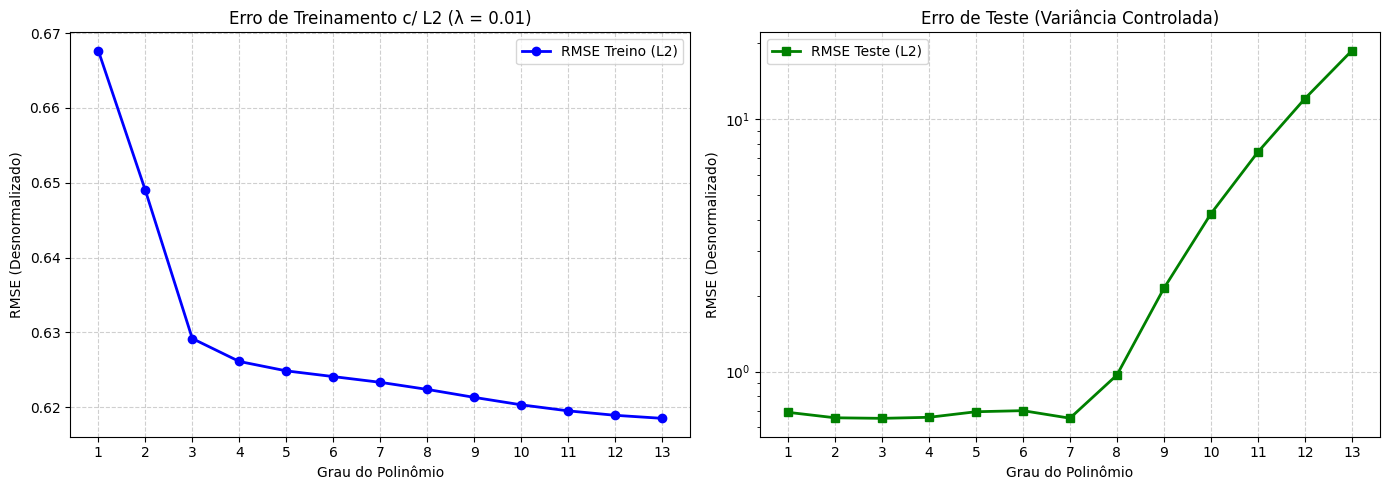

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# d) Treinamento e Avaliação com Regularização L2 (Ridge)
# ==========================================
lambda_l2 = 0.01

rmse_train_ridge = []
rmse_test_ridge = []
degrees_ridge = []

print(f"Treinando modelos com Regularização L2 (λ = {lambda_l2})...")

for degree in range(1, 14):
    # Recriação das features sem interações (from scratch)
    X_poly_train = create_polynomial_features(X_train_scaled, degree)
    X_poly_train = add_bias(X_poly_train)
    X_poly_test = create_polynomial_features(X_test_scaled, degree)
    X_poly_test = add_bias(X_poly_test)
    
    n_features = X_poly_train.shape[1]
    
    # 1. Montar a Matriz Identidade para a penalidade L2
    I = np.eye(n_features)
    
    # OTIMIZAÇÃO CRÍTICA: O Bias não deve ser penalizado!
    I[0, 0] = 0 
    
    # 2. Calcular theta usando a Equação Normal do Ridge
    A = X_poly_train.T @ X_poly_train + lambda_l2 * I
    b = X_poly_train.T @ y_train_scaled
    
    theta_ridge = np.linalg.solve(A, b)
    
    # 3. Predição em escala normalizada
    y_train_pred_scaled = X_poly_train @ theta_ridge
    y_test_pred_scaled = X_poly_test @ theta_ridge
    
    # 4. Desnormalizar a saída para dólar (escala real) antes de calcular o erro
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))
    
    # 5. Calcular RMSE
    rmse_train = np.sqrt(np.mean((y_train.ravel() - y_train_pred.ravel()) ** 2))
    rmse_test = np.sqrt(np.mean((y_test.ravel() - y_test_pred.ravel()) ** 2))
    
    rmse_train_ridge.append(rmse_train)
    rmse_test_ridge.append(rmse_test)
    degrees_ridge.append(degree)
    
    print(f"[Sucesso] Grau {degree:2d} | RMSE Teste: {rmse_test:10.2f}")

# ==========================================
# Geração dos Gráficos Comparativos (Treino vs Teste L2)
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico do Treino (L2)
plt.subplot(1, 2, 1)
plt.plot(degrees_ridge, rmse_train_ridge, marker='o', color='blue', linewidth=2, label='RMSE Treino (L2)')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE (Desnormalizado)')
plt.title(f'Erro de Treinamento c/ L2 (λ = {lambda_l2})')
plt.xticks(degrees_ridge)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfico do Teste (L2)
plt.subplot(1, 2, 2)
plt.plot(degrees_ridge, rmse_test_ridge, marker='s', color='green', linewidth=2, label='RMSE Teste (L2)')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE (Desnormalizado)')
plt.title('Erro de Teste (Variância Controlada)')
plt.xticks(degrees_ridge)
plt.yscale('log') # Mantido log para você poder comparar com o gráfico do item 'c' visualmente
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()
